# Coronary Stenosis — Data Exploration
**Input:** `roi_features_subset_b.csv` produced by the 1498-image feature extraction pipeline.

**Key facts about the CSV structure:**
- `roi_name` = `{patient_id}_{serie_id}_{frame}_{roi_idx}` where `roi_idx` ∈ [1, 100] are skeleton-sampled ROIs and `roi_idx ≥ 101` are forced GT-centred boxes (always stenosis=1 — must be **excluded from the test split**)
- 2191 feature columns: 30 raw (global + 4 tiles × 6 stats) + 2160 Gabor (72 filters × 30) + 1 `width_ratio`
- Target: `label` — 1 = stenosis, 0 = healthy

## 0 · Imports & config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from matplotlib.patches import Patch

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

# ── Update this path ──────────────────────────────────────────────────────────
CSV_PATH  = r"C:\Users\mluser\IPA_ML\notebooks\notebooks\csv_files\oriented_rois\roi_oriented_features_subset_1498.csv"

# ── Feature structure (must match feature_extraction constants) ───────────────
#STAT_NAMES  = ['mean', 'var', 'entropy', 'energy', 'kurtosis', 'skewness']
TILE_LABELS = ['tl', 'tr', 'bl', 'br']
N_SIZES        = 6
N_ORIENTATIONS = 12
N_FILTERS      = N_SIZES * N_ORIENTATIONS  # 72

META_COLS   = ['roi_name']
TARGET_COL  = 'label'

# ROI index threshold: roi_idx > FORCED_ROI_THRESHOLD are forced GT boxes
FORCED_ROI_THRESHOLD = 100

## 1 · Load & parse roi_name

In [2]:
df_all = pd.read_csv(CSV_PATH)

# Parse roi_name → patient_id, serie_id, frame_id, roi_idx
# Format: {patient_id}_{serie_id}_{frame_stem}_{roi_idx}
# roi_idx is the LAST token (always an integer)
def parse_roi_name(name):
    # Format: {patient}_{serie}_14_{patient}_{serie}_{frame}_{roi_idx}
    # tokens:    [0]      [1]  [2]    [3]      [4]     [5]      [-1]
    parts      = str(name).split('_')
    patient_id = parts[0]    # '002'
    serie_id   = parts[1]    # '5'
    frame_id   = parts[5]    # '0034'
    roi_idx    = int(parts[-1])  # 1
    return patient_id, serie_id, frame_id, roi_idx

parsed = df_all['roi_name'].apply(parse_roi_name)
df_all[['patient_id','serie_id','frame_id','roi_idx']] = pd.DataFrame(
    parsed.tolist(), index=df_all.index
)

# Flag forced GT boxes (roi_idx > 100)
df_all['is_forced_gt'] = df_all['roi_idx'] > FORCED_ROI_THRESHOLD

feature_cols = [c for c in df_all.columns
                if c not in META_COLS + [TARGET_COL,
                   'patient_id','serie_id','frame_id','roi_idx','is_forced_gt']]

print(f'Total ROIs        : {len(df_all):,}')
print(f'  skeleton-sampled: {(~df_all.is_forced_gt).sum():,}  (roi_idx 1-100)')
print(f'  forced GT boxes : {df_all.is_forced_gt.sum():,}   (roi_idx > 100, always stenosis=1)')
print(f'Feature columns   : {len(feature_cols)}')
print(f'Unique patients   : {df_all.patient_id.nunique()}')
print(f'Unique series     : {df_all.serie_id.nunique()}')
df_all.head(3)

Total ROIs        : 151,298
  skeleton-sampled: 149,800  (roi_idx 1-100)
  forced GT boxes : 1,498   (roi_idx > 100, always stenosis=1)
Feature columns   : 1398
Unique patients   : 64
Unique series     : 21


,roi_name,image_name,center_x,center_y,angle,width,height,label,gabor_f0_global_mean,gabor_f0_global_var,...,lbp_r2_bin14,lbp_r2_bin15,lbp_r2_bin16,lbp_r2_bin17,width_ratio,patient_id,serie_id,frame_id,roi_idx,is_forced_gt
0,002_5_14_002_5_0031_1,002_5_14_002_5_0031,188,104,138.366461,100,50,0,101.138161,25136.062500,...,0.0186,0.0118,0.0242,0.1000,51.0,002,5,0031,1,False
1,002_5_14_002_5_0031_2,002_5_14_002_5_0031,184,105,143.130102,100,50,0,99.224960,41409.835938,...,0.0170,0.0126,0.0228,0.0906,58.0,002,5,0031,2,False
2,002_5_14_002_5_0031_3,002_5_14_002_5_0031,182,105,0.000000,100,50,0,99.958427,176076.953125,...,0.0166,0.0116,0.0254,0.1030,71.0,002,5,0031,3,False


## 2 · df.info() and describe()

In [3]:
# 1 serie aleatoria por paciente
selected_series = (
    df_all.groupby('patient_id')['serie_id']
    .apply(lambda s: s.drop_duplicates()
                      .sample(n=1, random_state=RANDOM_STATE)
                      .iloc[0])
    .reset_index()
    .rename(columns={'serie_id': 'selected_serie'})
)

df = df_all.merge(
    selected_series,
    left_on  = ['patient_id', 'serie_id'],
    right_on = ['patient_id', 'selected_serie']
).drop(columns='selected_serie').reset_index(drop=True)

sampled = df[~df.is_forced_gt].copy()

print(f'Antes : {len(df_all):,} ROIs — {df_all.groupby(["patient_id","serie_id"]).ngroups} series')
print(f'Después: {len(df):,} ROIs — {df.patient_id.nunique()} pacientes × 1 serie')

Antes : 151,298 ROIs — 214 series
Después: 45,248 ROIs — 64 pacientes × 1 serie


In [4]:
df[feature_cols + [TARGET_COL]].info(verbose=False, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45248 entries, 0 to 45247
Columns: 1399 entries, image_name to label
dtypes: float64(1393), int64(5), object(1)
memory usage: 483.0+ MB


In [5]:
df[feature_cols].describe().T \
    .sort_values('std', ascending=False) \
    .head(20)

,count,mean,std,min,25%,50%,75%,max
gabor_f53_global_energy,45248.0,1.176450e+10,9.540493e+09,92909656.0,5.123162e+09,9.061749e+09,1.548408e+10,9.725374e+10
gabor_f29_global_energy,45248.0,1.183074e+10,9.507317e+09,109007424.0,5.192706e+09,9.040718e+09,1.565710e+10,1.166028e+11
gabor_f17_global_energy,45248.0,8.280595e+09,7.594682e+09,58886064.0,3.021804e+09,6.045166e+09,1.101514e+10,7.637597e+10
gabor_f65_global_energy,45248.0,8.224466e+09,7.517531e+09,65262276.0,3.016252e+09,6.049211e+09,1.095234e+10,8.841470e+10
gabor_f29_left_energy,45248.0,5.872493e+09,5.582450e+09,35655128.0,2.192285e+09,4.115015e+09,7.593361e+09,8.151463e+10
gabor_f53_left_energy,45248.0,5.784000e+09,5.561673e+09,45157308.0,2.126672e+09,4.022933e+09,7.435644e+09,6.523508e+10
gabor_f53_right_energy,45248.0,5.507084e+09,5.322324e+09,57313476.0,1.972673e+09,3.832516e+09,7.169717e+09,6.626052e+10
gabor_f29_right_energy,45248.0,5.477796e+09,5.277573e+09,56715280.0,1.983463e+09,3.788690e+09,7.067697e+09,6.192599e+10
gabor_f17_left_energy,45248.0,4.117244e+09,4.665934e+09,25729374.0,1.228573e+09,2.600074e+09,5.175023e+09,5.703057e+10
gabor_f65_left_energy,45248.0,4.064417e+09,4.514279e+09,30565874.0,1.245895e+09,2.629421e+09,5.109166e+09,6.184140e+10


## 3 · Missing values

In [6]:
nan_per_col = df[feature_cols].isna().sum()
nan_pct     = nan_per_col / len(df) * 100
nan_df      = pd.DataFrame({'n_missing': nan_per_col, 'pct_missing': nan_pct})
nan_df      = nan_df[nan_df.n_missing > 0].sort_values('pct_missing', ascending=False)

print(f'Features with NaNs: {len(nan_df)} / {len(feature_cols)}')

if len(nan_df):
    display(nan_df.head(20))
    # NaN rows by class & forced-GT flag
    nan_rows = df[df[feature_cols].isna().any(axis=1)]
    print('\nNaN rows by label:')
    print(nan_rows[TARGET_COL].value_counts().rename({0:'Healthy',1:'Stenosis'}))
    print('\nNaN rows are forced GT?')
    print(nan_rows['is_forced_gt'].value_counts())

    # Most problematic features
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.bar(range(len(nan_df)), nan_df.pct_missing, color='#E85D24', alpha=0.8)
    ax.set_xlabel('Feature (sorted by % missing)')
    ax.set_ylabel('% missing')
    ax.set_title('Missing values per feature')
    plt.tight_layout(); plt.show()
else:
    print('✓ No missing values.')

Features with NaNs: 0 / 1398
✓ No missing values.


## 4 · Forced GT boxes — the test-split contamination issue

ROIs with `roi_idx > 100` are forced GT-centred boxes injected during extraction so that every stenosis always has at least one positive ROI. They are **always label=1 by construction** and must be **removed from the test split** (they are not blind predictions — the model would see data it was designed to find).

Below we verify their properties and create the clean training-eligible DataFrame.

In [7]:
forced  = df[df.is_forced_gt]
sampled = df[~df.is_forced_gt]

print('=== Forced GT boxes (roi_idx > 100) ===')
print(f'  Count                : {len(forced):,}')
print(f'  label=1 (stenosis)   : {forced[TARGET_COL].sum():,}  ({forced[TARGET_COL].mean()*100:.1f}%)')
print(f'  label=0 (healthy)    : {(forced[TARGET_COL]==0).sum():,}  — should be 0')
print()
print('=== Skeleton-sampled ROIs (roi_idx 1-100) ===')
print(f'  Count                : {len(sampled):,}')
print(f'  label=1 (stenosis)   : {sampled[TARGET_COL].sum():,}  ({sampled[TARGET_COL].mean()*100:.2f}%)')
print(f'  label=0 (healthy)    : {(sampled[TARGET_COL]==0).sum():,}')
print()

# How many forced GT per image on average?
forced_per_image = forced.groupby(['patient_id','serie_id','frame_id']).size()
print(f'Forced GT boxes per image: mean={forced_per_image.mean():.2f}, max={forced_per_image.max()}')

# Recommendation
print()
print('ACTION: For the test split, use ONLY sampled ROIs (roi_idx <= 100).')
print('        Forced GT boxes may be kept in the TRAINING set to boost positive class.')

=== Forced GT boxes (roi_idx > 100) ===
  Count                : 448
  label=1 (stenosis)   : 418  (93.3%)
  label=0 (healthy)    : 12  — should be 0

=== Skeleton-sampled ROIs (roi_idx 1-100) ===
  Count                : 44,800
  label=1 (stenosis)   : -798  (-1.78%)
  label=0 (healthy)    : 39,532

Forced GT boxes per image: mean=1.00, max=1

ACTION: For the test split, use ONLY sampled ROIs (roi_idx <= 100).
        Forced GT boxes may be kept in the TRAINING set to boost positive class.


## 5 · Class distribution

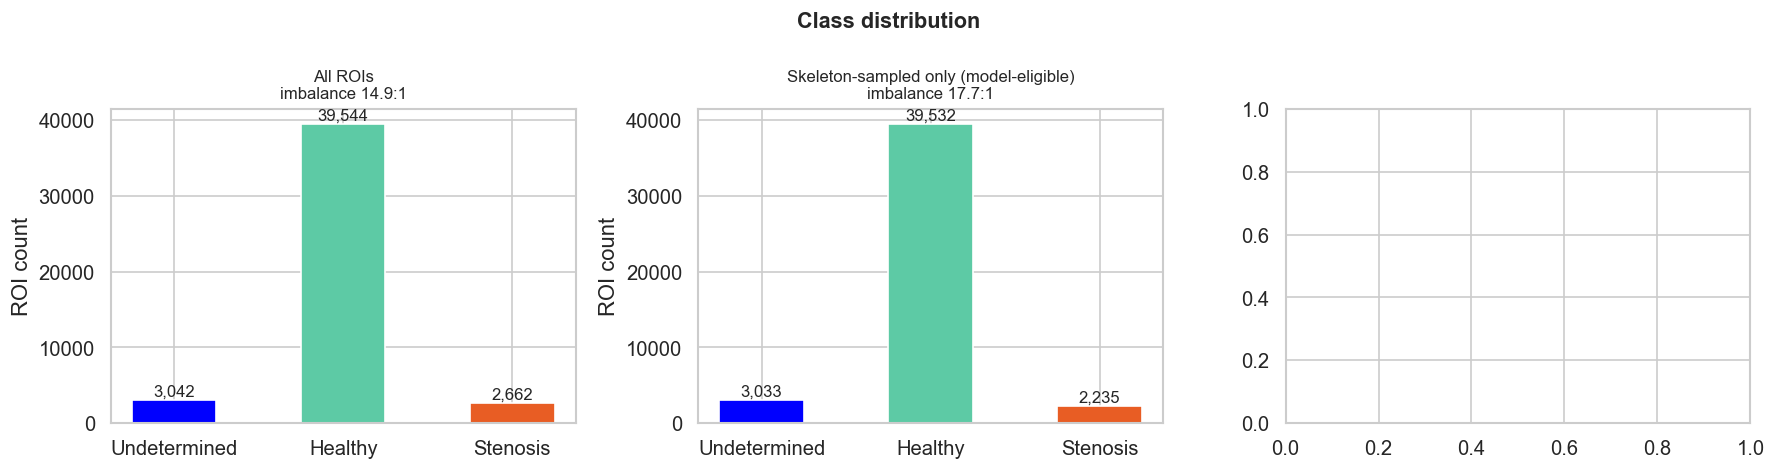

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

COLORS = {'Healthy': '#5DCAA5', 'Stenosis': '#E85D24', 'Undetermined': 'blue'}

for ax, subset, title in zip(
    axes,
    [df, sampled, forced],
    ['All ROIs', 'Skeleton-sampled only (model-eligible)']
):
    vc = subset[TARGET_COL].value_counts().sort_index()
    labels_map = {0:'Healthy', 1:'Stenosis', -1:'Undetermined'}
    names  = [labels_map[k] for k in vc.index]
    counts = vc.values
    colors = [COLORS[n] for n in names]
    bars = ax.bar(names, counts, color=colors, width=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(subset)*0.003,
                f'{count:,}', ha='center', va='bottom', fontsize=10)
    ratio = vc.get(0, 0) / max(vc.get(1, 1), 1)
    ax.set_title(f'{title}\nimbalance {ratio:.1f}:1', fontsize=10)
    ax.set_ylabel('ROI count')

plt.suptitle('Class distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Patients with ZERO stenosis ROIs (skeleton-sampled): 1
→ These are the patients relevant to Bria's sensitivity question.



,n_total,n_healthy,n_stenosis
patient_id,,,
091,700,700,0


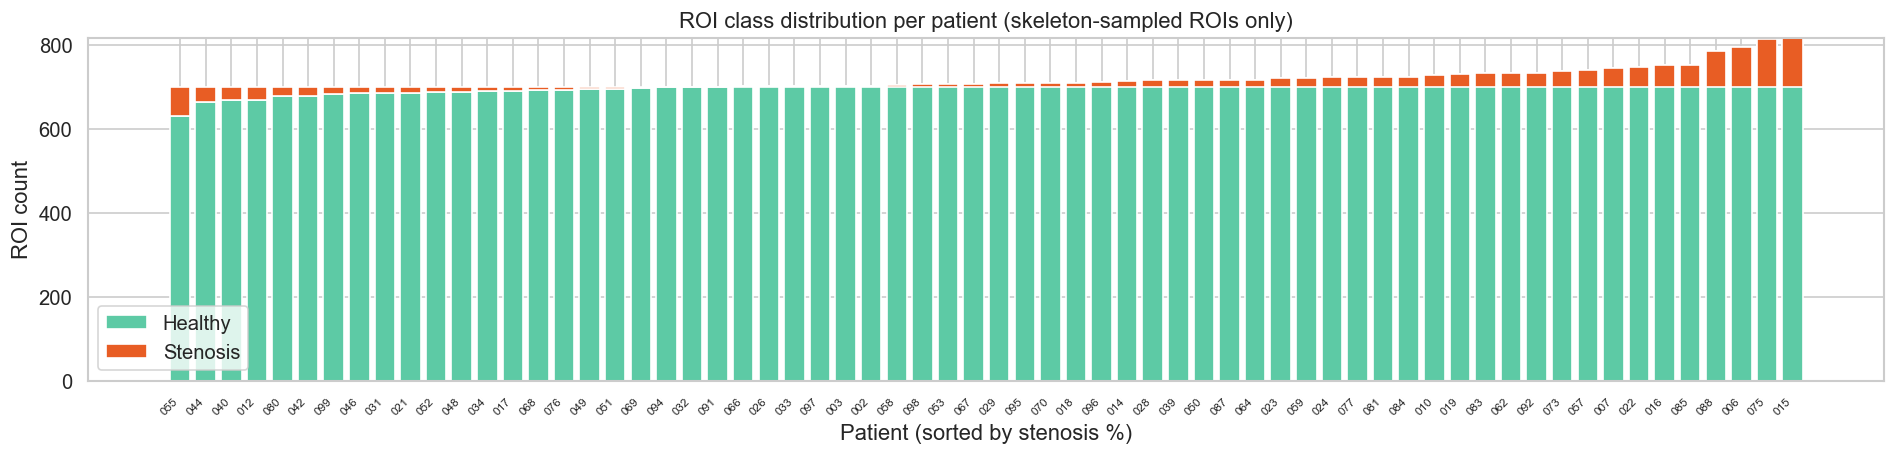

In [9]:
# Per-patient stenosis ROI count (skeleton-sampled only)
per_patient = sampled.groupby('patient_id')[TARGET_COL].agg(
    n_stenosis='sum', n_total='count'
)
per_patient['n_healthy']    = per_patient.n_total - per_patient.n_stenosis
per_patient['stenosis_pct'] = per_patient.n_stenosis / per_patient.n_total * 100

zero_stenosis_patients = (per_patient.n_stenosis == 0).sum()
print(f'Patients with ZERO stenosis ROIs (skeleton-sampled): {zero_stenosis_patients}')
print('→ These are the patients relevant to Bria\'s sensitivity question.')
print()
display(per_patient[per_patient.n_stenosis == 0][['n_total','n_healthy','n_stenosis']])

fig, ax = plt.subplots(figsize=(16, 4))
per_patient_sorted = per_patient.sort_values('stenosis_pct', ascending=False)
x = range(len(per_patient_sorted))
ax.bar(x, per_patient_sorted.n_healthy,  color='#5DCAA5', label='Healthy')
ax.bar(x, per_patient_sorted.n_stenosis, bottom=per_patient_sorted.n_healthy,
       color='#E85D24', label='Stenosis')
ax.set_xticks(list(x))
ax.set_xticklabels(per_patient_sorted.index, rotation=45, ha='right', fontsize=7)
ax.set_xlabel('Patient (sorted by stenosis %)')
ax.set_ylabel('ROI count')
ax.set_title('ROI class distribution per patient (skeleton-sampled ROIs only)')
ax.legend()
plt.tight_layout()
plt.show()

## 6 · Feature group breakdown

Column naming convention: `raw_global_{stat}`, `raw_{tile}_{stat}`, `gabor_f{i}_global_{stat}`, `gabor_f{i}_{tile}_{stat}`, `width_ratio`

In [10]:
def classify_col(col):
    if col == 'width_ratio':
        return 'raw', 'width_ratio', 'width_ratio'
    parts  = col.split('_')
    source = parts[0]           # 'raw' or 'gabor'
    stat   = parts[-1]          # last token is always the stat name
    # region is everything between source and stat
    middle = parts[1:-1]        # e.g. ['global'] or ['f12', 'tl'] or ['f12', 'global']
    if 'global' in middle:
        region = 'global'
    else:
        region = next((t for t in middle if t in TILE_LABELS), 'other')
    return source, region, stat

meta_df = pd.DataFrame(
    [classify_col(c) for c in feature_cols],
    columns=['source','region','stat'],
    index=feature_cols
)

print('Feature count by source:')
print(meta_df.source.value_counts().to_string())
print()
print('Feature count by region:')
print(meta_df.region.value_counts().to_string())
print()
print('Feature count by stat:')
print(meta_df.stat.value_counts().to_string())

Feature count by source:
source
gabor     1296
paper       49
lbp         28
raw         19
center       2
image        1
height       1
angle        1
width        1

Feature count by region:
region
other          959
global         438
width_ratio      1

Feature count by stat:
stat
entropy         225
mean            223
var             223
kurtosis        219
skewness        219
energy          219
correlation       2
x                 2
width             2
y                 2
idm               2
variance          2
asm               2
contrast          2
avg               2
mcc               2
imc2              2
imc1              2
bin9              2
cv                2
bin8              2
min               2
max               2
std               2
bin1              2
bin2              2
bin0              2
bin5              2
bin4              2
bin7              2
bin6              2
bin3              2
name              1
angle             1
height            1
tortuosity    

## 7 · Correlation with target label

In [11]:
# Work on skeleton-sampled ROIs only for unbiased analysis
corr = sampled[feature_cols].corrwith(sampled[TARGET_COL]).sort_values(key=abs, ascending=False)

print('Top 25 features most correlated with stenosis label (skeleton-sampled ROIs):')
print(corr.head(25).to_string())

C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top 25 features most correlated with stenosis label (skeleton-sampled ROIs):
raw_global_skewness         -0.038299
gabor_f30_global_skewness    0.037769
paper_weli_gradient_mean     0.036358
paper_weli_n_segments       -0.036235
raw_right_skewness          -0.034043
raw_left_skewness           -0.034034
gabor_f30_right_skewness     0.033858
gabor_f31_global_skewness    0.031322
gabor_f36_right_skewness     0.030693
gabor_f29_global_skewness   -0.030680
gabor_f34_right_energy       0.030155
gabor_f26_right_energy       0.029651
gabor_f26_right_var          0.029600
gabor_f41_right_energy       0.029418
gabor_f38_global_kurtosis   -0.028771
gabor_f40_right_energy       0.028742
gabor_f35_right_energy       0.028473
gabor_f33_right_energy       0.028399
gabor_f33_right_var          0.028368
gabor_f31_right_energy       0.028066
gabor_f31_right_var          0.027990
gabor_f25_right_energy       0.027712
gabor_f25_right_var          0.027617
gabor_f34_right_var          0.027567
gabor_f27_r

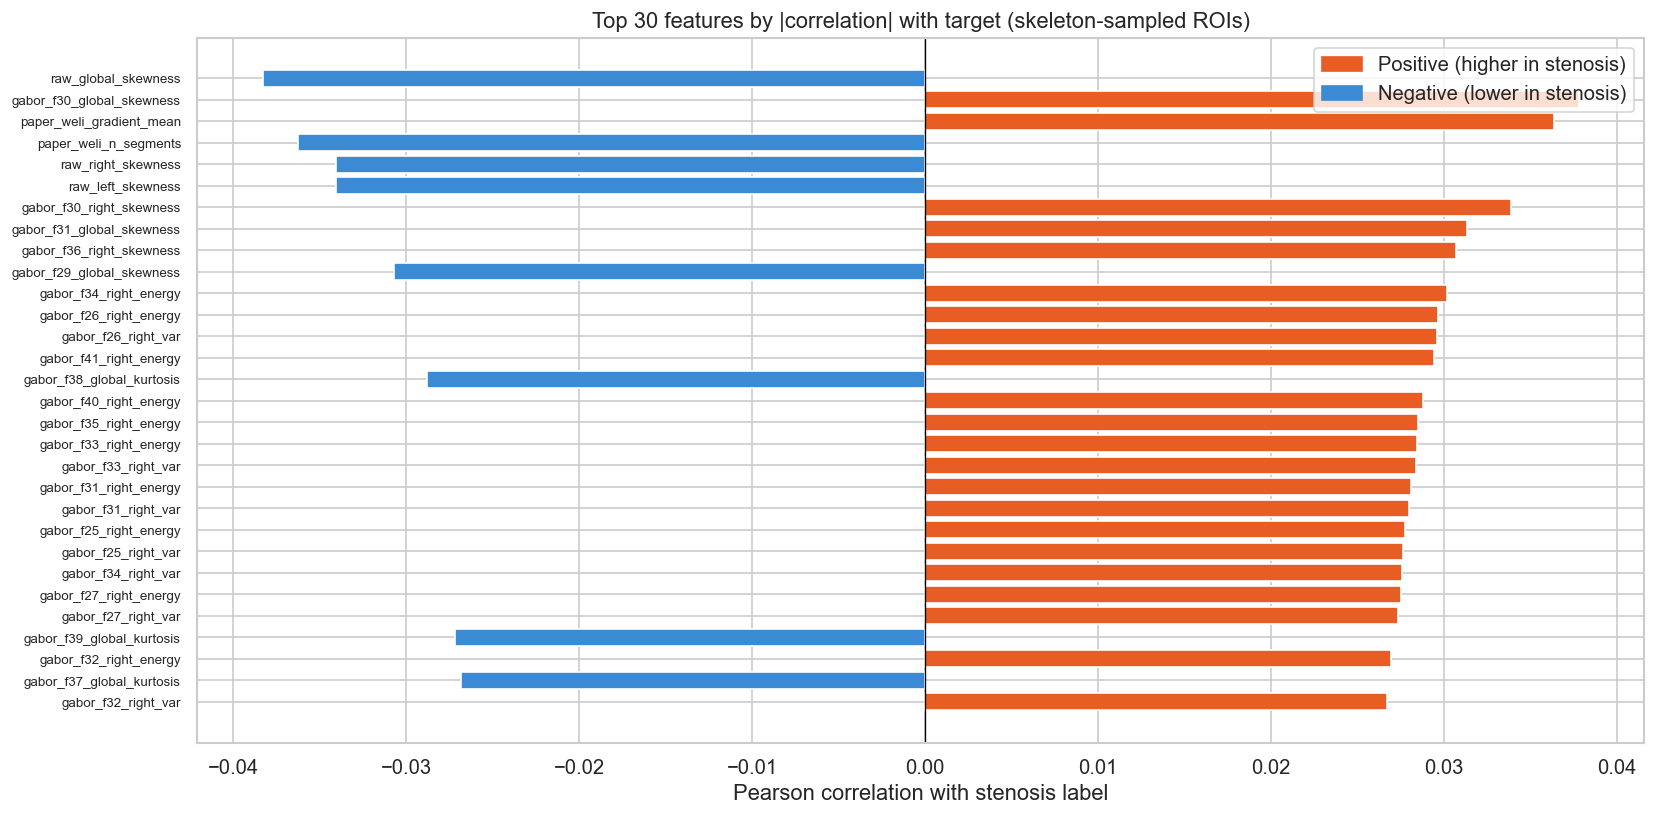

In [12]:
# Bar chart — top 30 by |correlation|
top30 = corr.abs().nlargest(30)
bar_colors = ['#E85D24' if corr[f] > 0 else '#3B8BD4' for f in top30.index]

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(range(len(top30)), corr[top30.index].values, color=bar_colors)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with stenosis label')
ax.set_title('Top 30 features by |correlation| with target (skeleton-sampled ROIs)')
ax.invert_yaxis()
ax.legend(handles=[
    Patch(color='#E85D24', label='Positive (higher in stenosis)'),
    Patch(color='#3B8BD4', label='Negative (lower in stenosis)')
])
plt.tight_layout()
plt.show()

In [13]:
# Correlation broken down by stat type — which stat family is most discriminative?
#stat_corr = {}
#for stat in STAT_NAMES + ['width_ratio']:
#    stat_cols = meta_df[meta_df.stat == stat].index.tolist()
#    if stat_cols:
#        stat_corr[stat] = corr[stat_cols].abs().mean()

#stat_corr_s = pd.Series(stat_corr).sort_values(ascending=False)
#print('Mean |correlation| with label per stat family:')
#print(stat_corr_s.to_string())

#fig, ax = plt.subplots(figsize=(8, 3))
#ax.bar(stat_corr_s.index, stat_corr_s.values, color='#3B8BD4', alpha=0.8)
#ax.set_ylabel('Mean |Pearson r| with label')
#ax.set_title('Average discriminative power per stat family')
#plt.tight_layout()
#plt.show()

## 8 · ANOVA F-test — univariate feature ranking

In [14]:
# Definir correctamente las columnas de metadata a excluir
META_COLS = ['roi_name', 'image_name', 'center_x', 'center_y',
             'angle', 'width', 'height', 'label',
             'patient_id', 'serie_id', 'frame_id', 'roi_idx', 'is_forced_gt']

feature_cols = [c for c in sampled.columns if c not in META_COLS]

# Verificar que todas son numéricas
print(f"Feature columns: {len(feature_cols)}")
print(f"Non-numeric: {sampled[feature_cols].select_dtypes(exclude='number').columns.tolist()}")

# Ahora sí
X_sampled = sampled[feature_cols].fillna(sampled[feature_cols].median())
y_sampled = sampled[TARGET_COL]

f_scores, p_values = f_classif(X_sampled, y_sampled)

anova_df = pd.DataFrame({
    'feature': feature_cols,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values('F_score', ascending=False).reset_index(drop=True)

sig = (anova_df.p_value < 0.05).sum()
print(f'Features significant at p<0.05: {sig} / {len(feature_cols)}')
print(f'\nTop 20 by ANOVA F-score:')
display(anova_df.head(20))

Feature columns: 1392
Non-numeric: []
Features significant at p<0.05: 1089 / 1392

Top 20 by ANOVA F-score:


,feature,F_score,p_value
0,raw_global_var,715.077547,1.995181e-306
1,paper_px_std,667.890094,1.511894e-286
2,paper_haralick_sum_entropy,642.732238,6.235454e-276
3,raw_left_var,621.858781,4.085226e-267
4,paper_haralick_entropy,621.408853,6.329078e-267
5,lbp_r2_bin11,543.049662,9.335638e-234
6,paper_haralick_imc2,535.056994,2.289496e-230
7,gabor_f53_global_energy,531.587349,6.784895e-229
8,gabor_f53_global_var,531.128894,1.061778e-228
9,paper_haralick_variance,518.997346,1.492862e-223


In [15]:
# F-score mean per stat family
anova_df['stat'] = anova_df.feature.apply(lambda c: classify_col(c)[2])
anova_df['source'] = anova_df.feature.apply(lambda c: classify_col(c)[0])
anova_df['region'] = anova_df.feature.apply(lambda c: classify_col(c)[1])

print('Mean F-score per stat family:')
print(anova_df.groupby('stat')['F_score'].mean().sort_values(ascending=False).to_string())
print()
print('Mean F-score raw vs gabor:')
print(anova_df.groupby('source')['F_score'].mean().sort_values(ascending=False).to_string())
print()
print('Mean F-score global vs tiles:')
print(anova_df.groupby('region')['F_score'].mean().sort_values(ascending=False).to_string())

Mean F-score per stat family:
stat
bin11           543.049662
bin10           417.678996
std             342.634710
cv              337.440659
asm             334.779279
density         329.099415
px              329.099412
mcc             312.403255
variance        311.485077
imc2            300.850001
imc1            283.669813
bin12           275.492301
correlation     269.415667
bin8            267.140919
width           232.163805
var             197.635821
energy          190.976855
contrast        162.426627
bin4            160.615683
bin5            151.231489
idm             145.706505
bin16           135.166824
min             119.858122
max             117.543291
bin13           114.114608
bin6            112.609946
bin3            107.148204
segments         64.461299
avg              63.551456
bin7             58.568395
bin17            49.595300
bin14            38.085278
kurtosis         34.892256
bin0             34.585326
bin15            25.412282
bin2             19.

C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Pass

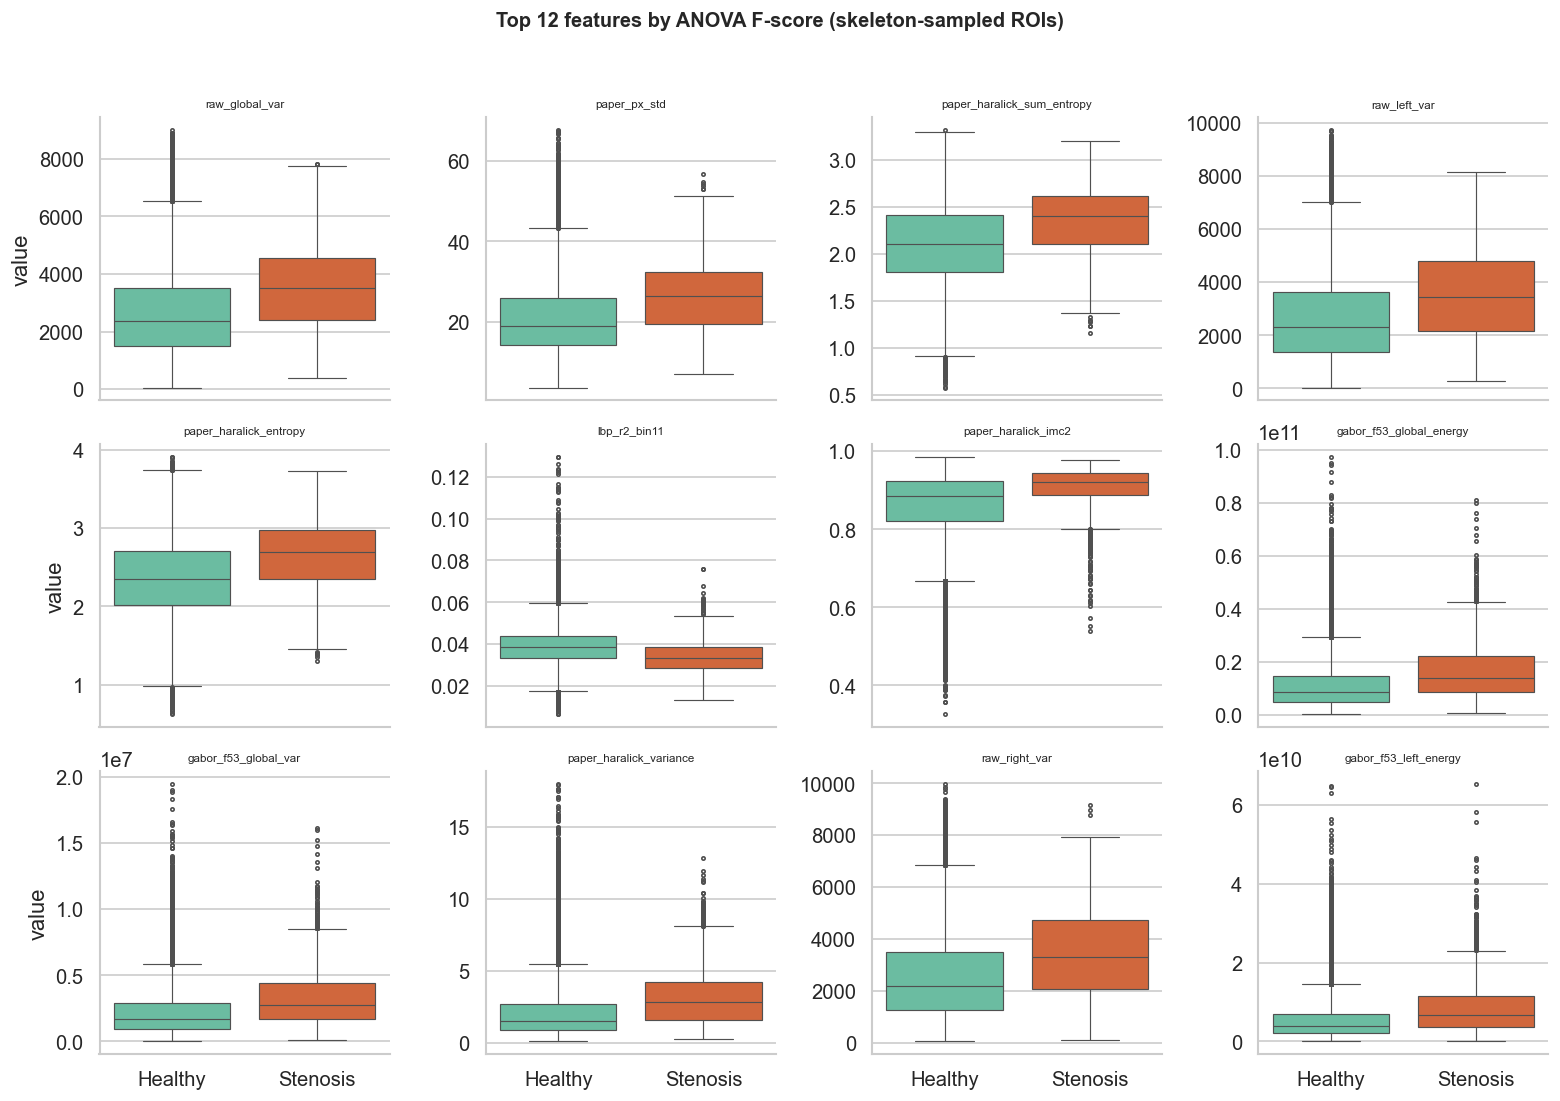

In [16]:
# Boxplots for top 12 features
top12 = anova_df.head(12).feature.tolist()
plot_df = sampled[top12 + [TARGET_COL]].melt(id_vars=TARGET_COL, var_name='feature', value_name='value')
plot_df['class'] = plot_df[TARGET_COL].map({0:'Healthy', 1:'Stenosis'})

g = sns.FacetGrid(plot_df, col='feature', col_wrap=4, height=3, aspect=1.1, sharey=False)
g.map_dataframe(sns.boxplot, x='class', y='value',
                palette={'Healthy':'#5DCAA5','Stenosis':'#E85D24'},
                linewidth=0.7, fliersize=2)
g.set_titles(col_template='{col_name}', size=7)
g.set_axis_labels('', 'value')
plt.suptitle('Top 12 features by ANOVA F-score (skeleton-sampled ROIs)', y=1.02,
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Selection with Random Forest

Pacientes problemáticos forzados a test: ['026', '044', '087', '091']
Split real : 75.0% / 25.0%
df shape antes del split: (45248, 1405)
roi_idx
101    448
Train ROIs : 33,936  (label=1: 2,108, label=-1: 2,461)
Test ROIs  : 11,200   (label=1: 455, label=-1: 580)
Train patients: 48 | Test patients: 16
Leakage check: 0 pacientes en ambos  ✓

y_train: {0: np.int64(29367), 1: np.int64(2108)}
y_test : {0: np.int64(10745), 1: np.int64(455)}

Top 50 features seleccionadas por RF:
gabor_f35_global_energy       0.006837
paper_haralick_variance       0.006812
raw_global_var                0.006697
paper_px_std                  0.006492
lbp_r2_bin8                   0.005928
paper_haralick_correlation    0.005757
paper_weli_grey_cv            0.005495
gabor_f47_global_energy       0.005430
lbp_r2_bin11                  0.005251
paper_haralick_imc2           0.005121
gabor_f29_right_var           0.004938
gabor_f29_right_energy        0.004764
lbp_r2_bin10                  0.004604
gabor_f34_right

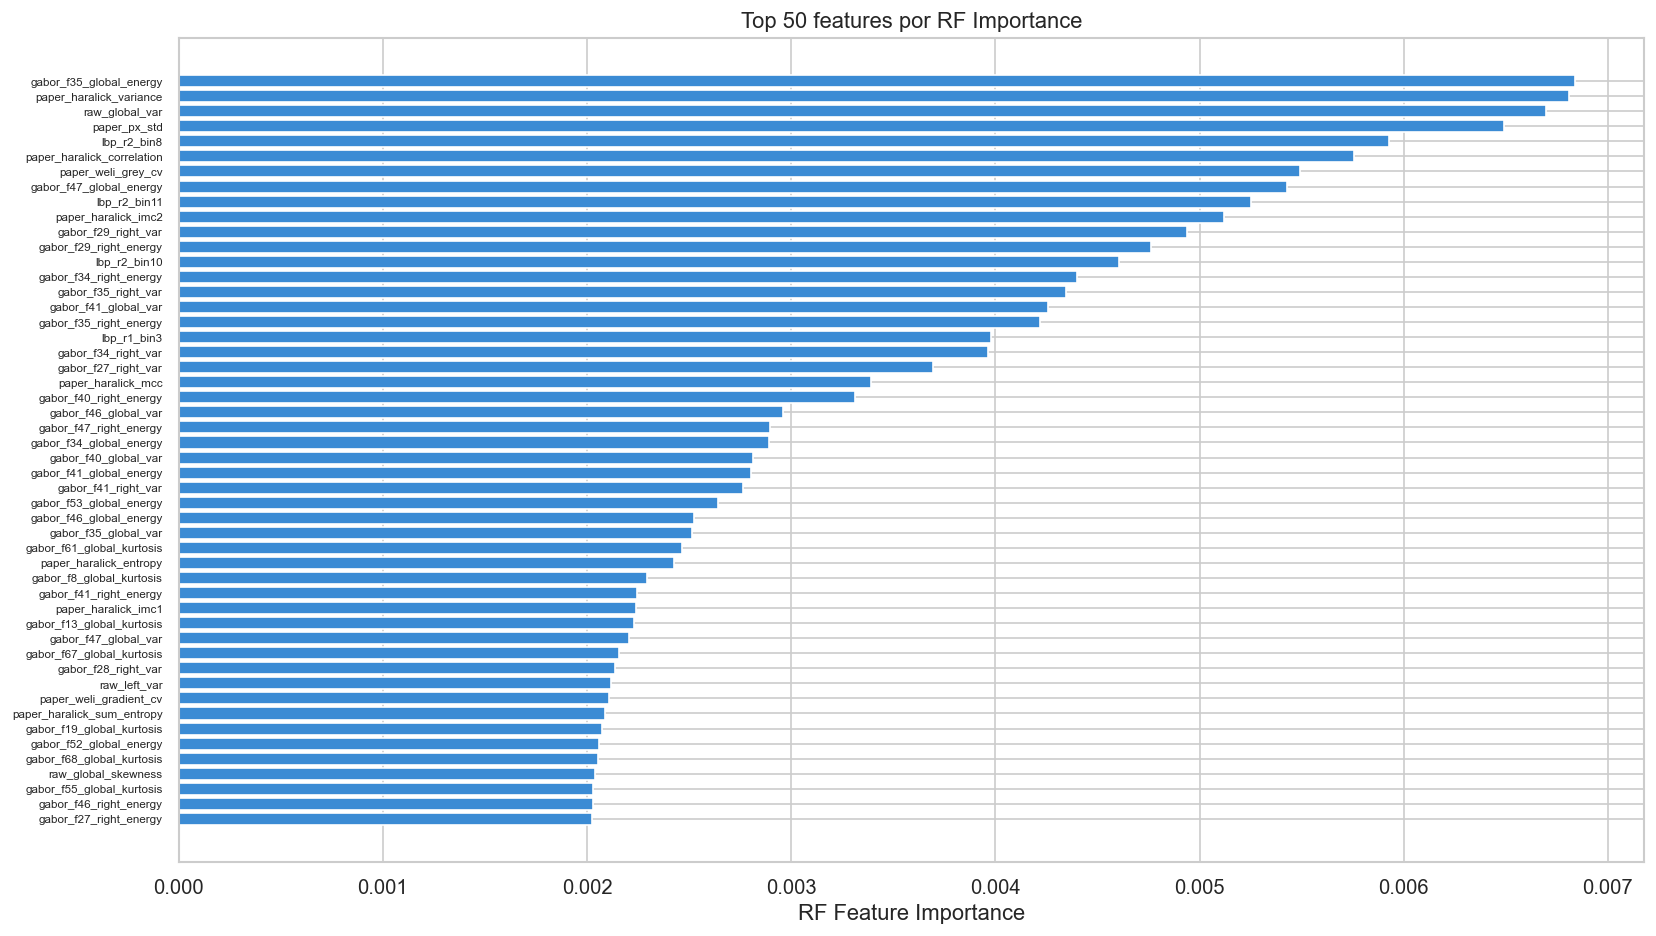


Shape train después de selección: (31475, 50)
Shape test  después de selección: (11200, 50)


In [25]:
## 15 · Train/Test split + RF Feature Selection
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

# ── 1. Split a nivel PACIENTE (evita leakage) ────────────────────────────────
# Identificar pacientes problemáticos (forced GT con label=0)
problem_patients = (
    df[(df['roi_idx'] > 100) & (df[TARGET_COL] == 0)]
    ['patient_id'].unique().tolist()
)
print(f"Pacientes problemáticos forzados a test: {problem_patients}")

# Split solo sobre pacientes no problemáticos
remaining_patients = [p for p in sampled['patient_id'].unique()
                      if p not in problem_patients]

patients_train, patients_test_remaining = train_test_split(
    remaining_patients, test_size=0.2, random_state=RANDOM_STATE
)

# Añadir problemáticos a test
patients_test = list(patients_test_remaining) + problem_patients

total = len(patients_train) + len(patients_test)
print(f"Split real : {len(patients_train)/total*100:.1f}% / {len(patients_test)/total*100:.1f}%")

# Train: sampled + forced GT (señal positiva extra)
print(f"df shape antes del split: {df.shape}")
rpf_check = df.groupby(['patient_id','serie_id','frame_id'])['roi_idx'].count()
print(rpf_check.value_counts().sort_index().to_string())

train_df = df[df['patient_id'].isin(patients_train)].copy()
# Test: SOLO sampled, sin forced GT
test_df  = sampled[sampled['patient_id'].isin(patients_test)].copy()

print(f'Train ROIs : {len(train_df):,}  '
      f'(label=1: {(train_df[TARGET_COL]==1).sum():,}, '
      f'label=-1: {(train_df[TARGET_COL]==-1).sum():,})')
print(f'Test ROIs  : {len(test_df):,}   '
      f'(label=1: {(test_df[TARGET_COL]==1).sum():,}, '
      f'label=-1: {(test_df[TARGET_COL]==-1).sum():,})')
print(f'Train patients: {len(patients_train)} | Test patients: {len(patients_test)}')

# Leakage check
overlap = set(patients_train) & set(patients_test)
print(f"Leakage check: {len(overlap)} pacientes en ambos  {'✓' if len(overlap)==0 else '⚠️'}")

# ── 2. Preparar X/y ──────────────────────────────────────────────────────────
# Mapear -1 → 1 en train (undetermined = stenosis para entrenar)
train_df = train_df[train_df[TARGET_COL] != -1].copy()
# Mapear -1 → 1 en test (undetermined = stenosis para evaluar)
test_df[TARGET_COL]  = test_df[TARGET_COL].replace(-1, 0)

X_train = train_df[feature_cols].fillna(train_df[feature_cols].median())
y_train = train_df[TARGET_COL]
X_test  = test_df[feature_cols].fillna(X_train.median())
y_test  = test_df[TARGET_COL]

print(f'\ny_train: {dict(y_train.value_counts().sort_index())}')
print(f'y_test : {dict(y_test.value_counts().sort_index())}')

# ── 3. Escalar ────────────────────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 4. RF Feature Importance ──────────────────────────────────────────────────
rf_selector = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_selector.fit(X_train_scaled, y_train)
importances       = pd.Series(rf_selector.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)

TOP_K        = 50
top_features = importances_sorted.head(TOP_K).index.tolist()
print(f'\nTop {TOP_K} features seleccionadas por RF:')
print(importances_sorted.head(TOP_K).to_string())

# ── 5. Visualizar importancias ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(range(TOP_K), importances_sorted.head(TOP_K).values[::-1], color='#3B8BD4')
ax.set_yticks(range(TOP_K))
ax.set_yticklabels(importances_sorted.head(TOP_K).index[::-1], fontsize=7)
ax.set_xlabel('RF Feature Importance')
ax.set_title(f'Top {TOP_K} features por RF Importance')
plt.tight_layout()
plt.show()

# ── 6. Aplicar selección ──────────────────────────────────────────────────────
X_train_sel = X_train_scaled[:, [feature_cols.index(f) for f in top_features]]
X_test_sel  = X_test_scaled[:,  [feature_cols.index(f) for f in top_features]]
print(f'\nShape train después de selección: {X_train_sel.shape}')
print(f'Shape test  después de selección: {X_test_sel.shape}')

In [18]:
# ── Verificar integridad del split ────────────────────────────
print("=== TRAIN ===")
print(f"  Pacientes  : {len(patients_train)}")
print(f"  ROIs total : {len(train_df):,}")
print(f"  label= 1   : {(train_df[TARGET_COL]==1).sum():,}")
print(f"  label=-1   : {(train_df[TARGET_COL]==-1).sum():,}")
print(f"  label= 0   : {(train_df[TARGET_COL]==0).sum():,}")

print("\n=== TEST ===")
print(f"  Pacientes  : {len(patients_test)}")
print(f"  ROIs total : {len(test_df):,}")
print(f"  label= 1   : {(test_df[TARGET_COL]==1).sum():,}")
print(f"  label=-1   : {(test_df[TARGET_COL]==-1).sum():,}")
print(f"  label= 0   : {(test_df[TARGET_COL]==0).sum():,}")

# ── Verificar que no hay pacientes en ambos splits ────────────
overlap = set(patients_train) & set(patients_test)
print(f"\nLeakage check — pacientes en ambos splits: {len(overlap)}  ✓" 
      if len(overlap)==0 else f"⚠️  LEAKAGE: {overlap}")

# ── Verificar imágenes sin stenosis en train ──────────────────
# Usar label==1 OR label==-1 como "tiene lesión"
train_has_lesion = (
    train_df.groupby('image_name')[TARGET_COL]
    .apply(lambda x: ((x==1)|(x==-1)).any())
)
n_no_lesion = (~train_has_lesion).sum()
print(f"\nImágenes train sin ningún ROI de lesión (1 o -1): {n_no_lesion}")
if n_no_lesion > 0:
    print("  →", train_has_lesion[~train_has_lesion].index.tolist())

# ── Verificar que y_train no tiene -1 si vas a usar RF ────────
print(f"\ny_train valores únicos: {sorted(y_train.unique())}")
if -1 in y_train.values:
    print("⚠️  y_train contiene -1 — RF no lo espera, considera:")
    print("   opción A: excluir -1  →  train_df = train_df[train_df[TARGET_COL] != -1]")
    print("   opción B: mapear -1→1 →  train_df[TARGET_COL] = train_df[TARGET_COL].replace(-1, 1)")

=== TRAIN ===
  Pacientes  : 48
  ROIs total : 31,475
  label= 1   : 2,108
  label=-1   : 0
  label= 0   : 29,367

=== TEST ===
  Pacientes  : 16
  ROIs total : 11,200
  label= 1   : 455
  label=-1   : 0
  label= 0   : 10,745

Leakage check — pacientes en ambos splits: 0  ✓

Imágenes train sin ningún ROI de lesión (1 o -1): 7
  → ['006_1_14_006_1_0096', '006_1_14_006_1_0097', '006_1_14_006_1_0098', '006_1_14_006_1_0099', '029_1_14_029_1_0047', '029_1_14_029_1_0048', '029_1_14_029_1_0052']

y_train valores únicos: [np.int64(0), np.int64(1)]


In [19]:
# ── Verificar que train y test contienen 7 frames por serie ──────────────────

print("=== Frames por serie en TRAIN ===")
train_frames = (
    train_df.groupby(['patient_id', 'serie_id'])['frame_id']
    .nunique()
    .reset_index(name='n_frames')
)
count_train = train_frames['n_frames'].value_counts().sort_index()
print(count_train.to_string())
print(f"\nSeries con != 7 frames en TRAIN: {(train_frames['n_frames'] != 7).sum()}")
bad_train = train_frames[train_frames['n_frames'] != 7]
if len(bad_train):
    print(bad_train.to_string())

print("\n=== Frames por serie en TEST ===")
test_frames = (
    test_df.groupby(['patient_id', 'serie_id'])['frame_id']
    .nunique()
    .reset_index(name='n_frames')
)
count_test = test_frames['n_frames'].value_counts().sort_index()
print(count_test.to_string())
print(f"\nSeries con != 7 frames en TEST: {(test_frames['n_frames'] != 7).sum()}")
bad_test = test_frames[test_frames['n_frames'] != 7]
if len(bad_test):
    print(bad_test.to_string())

print("\n=== Resumen global ===")
all_frames = (
    df_all.groupby(['patient_id', 'serie_id'])['frame_id']
    .nunique()
    .reset_index(name='n_frames')
)
print(f"Total series en df_all          : {len(all_frames)}")
print(f"Series con exactamente 7 frames : {(all_frames['n_frames'] == 7).sum()}")
print(f"Series con != 7 frames          : {(all_frames['n_frames'] != 7).sum()}")
if (all_frames['n_frames'] != 7).any():
    print("\nSeries problemáticas en df_all:")
    print(all_frames[all_frames['n_frames'] != 7].to_string())

=== Frames por serie en TRAIN ===
n_frames
7    48

Series con != 7 frames en TRAIN: 0

=== Frames por serie en TEST ===
n_frames
7    16

Series con != 7 frames en TEST: 0

=== Resumen global ===
Total series en df_all          : 214
Series con exactamente 7 frames : 214
Series con != 7 frames          : 0


In [24]:
# ── ROIs per frame distribution ───────────────────────────────────────────────

def rois_per_frame_summary(dataframe, label):
    rpf = (
        dataframe.groupby(['patient_id', 'serie_id', 'frame_id'])['roi_idx']
        .count()
        .reset_index(name='n_rois')
    )
    print(f"\n=== {label} ===")
    print(f"  Total frames     : {len(rpf)}")
    print(f"  ROIs per frame   : mean={rpf.n_rois.mean():.1f}  "
          f"min={rpf.n_rois.min()}  max={rpf.n_rois.max()}  "
          f"median={rpf.n_rois.median():.0f}")
    print(f"  Distribution:")
    print(rpf.n_rois.value_counts().sort_index().to_string())
    return rpf

rpf_all   = rois_per_frame_summary(df_all,   "INITIAL DATASET (df_all, all ROIs)")
rpf_train = rois_per_frame_summary(train_df, "TRAIN (skeleton + forced GT)")
rpf_test  = rois_per_frame_summary(test_df,  "TEST  (skeleton only, no forced GT)")


=== INITIAL DATASET (df_all, all ROIs) ===
  Total frames     : 1498
  ROIs per frame   : mean=101.0  min=101  max=101  median=101
  Distribution:
n_rois
101    1498

=== TRAIN (skeleton + forced GT) ===
  Total frames     : 336
  ROIs per frame   : mean=93.7  min=69  max=101  median=96
  Distribution:
n_rois
69      1
72      1
73      1
75      1
77      2
79      1
81      4
82      3
83      9
84      5
85      4
86      7
87      8
88      5
89     10
90     17
91     19
92     12
93     13
94     20
95     25
96     38
97     37
98     43
99     33
100    14
101     3

=== TEST  (skeleton only, no forced GT) ===
  Total frames     : 112
  ROIs per frame   : mean=100.0  min=100  max=100  median=100
  Distribution:
n_rois
100    112


In [21]:
print(df.columns)

Index(['roi_name', 'image_name', 'center_x', 'center_y', 'angle', 'width',
       'height', 'label', 'gabor_f0_global_mean', 'gabor_f0_global_var',
       ...
       'lbp_r2_bin14', 'lbp_r2_bin15', 'lbp_r2_bin16', 'lbp_r2_bin17',
       'width_ratio', 'patient_id', 'serie_id', 'frame_id', 'roi_idx',
       'is_forced_gt'],
      dtype='object', length=1405)


In [22]:
## 16 · Guardar top 50 features en CSV + scaler

import pickle

top50_cols = top_features  # ya definido en el paso anterior

# Train y test con solo las top 50 features + metadatos útiles
train_out = train_df[['roi_name', 'patient_id', 'serie_id', 'frame_id', 
                       'roi_idx', 'is_forced_gt', TARGET_COL] + top50_cols].copy()

test_out  = test_df[['roi_name', 'patient_id', 'serie_id', 'frame_id', 
                      'roi_idx', 'is_forced_gt', TARGET_COL] + top50_cols].copy()

# Guardar CSVs
train_out.to_csv('train_top50_features_ORIENTED.csv', index=False)
test_out.to_csv('test_top50_features_ORIENTED.csv', index=False)

# Guardar lista de features (útil para recargar en orden correcto)
with open('top50_feature_names.pkl', 'wb') as f:
    pickle.dump(top50_cols, f)

print(f'Train CSV : {train_out.shape}  → train_top50_features.csv')
print(f'Test CSV  : {test_out.shape}   → test_top50_features.csv')
print(f'Scaler    → scaler_top50.pkl')
print(f'Features  → top50_feature_names.pkl')

Train CSV : (31475, 57)  → train_top50_features.csv
Test CSV  : (11200, 57)   → test_top50_features.csv
Scaler    → scaler_top50.pkl
Features  → top50_feature_names.pkl


In [23]:
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
# ── Reemplazar StandardScaler por MinMaxScaler ────────────────
scaler_minmax = MinMaxScaler()

X_train_sel_norm = scaler_minmax.fit_transform(X_train_sel)
X_test_sel_norm  = scaler_minmax.transform(X_test_sel)

# Verificar rango
print(f"Train min: {X_train_sel_norm.min():.3f}  max: {X_train_sel_norm.max():.3f}")
print(f"Test  min: {X_test_sel_norm.min():.3f}  max: {X_test_sel_norm.max():.3f}")

# ── Exportar ──────────────────────────────────────────────────
train_pos = X_train_sel_norm[y_train.values == 1]
train_neg = X_train_sel_norm[y_train.values == 0]
test_pos  = X_test_sel_norm[y_test.values == 1]
test_neg  = X_test_sel_norm[y_test.values == 0]

OUTPUT_DIR = Path(r"C:\Users\mluser\IPA_ML\notebooks\notebooks\csv_files\oriented_rois\ucasML")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame(train_pos).to_csv(OUTPUT_DIR / "train_positive.csv", header=False, index=False)
pd.DataFrame(train_neg).to_csv(OUTPUT_DIR / "train_negative.csv", header=False, index=False)
pd.DataFrame(test_pos).to_csv(OUTPUT_DIR / "test_positive.csv",   header=False, index=False)
pd.DataFrame(test_neg).to_csv(OUTPUT_DIR / "test_negative.csv",   header=False, index=False)

print(f"\ntrain_positive : {len(train_pos):,} rows")
print(f"train_negative : {len(train_neg):,} rows")
print(f"test_positive  : {len(test_pos):,} rows")
print(f"test_negative  : {len(test_neg):,} rows")

Train min: 0.000  max: 1.000
Test  min: -0.000  max: 1.247

train_positive : 2,108 rows
train_negative : 29,367 rows
test_positive  : 455 rows
test_negative  : 10,745 rows


## 9 · width_ratio — the stenosis-specific feature

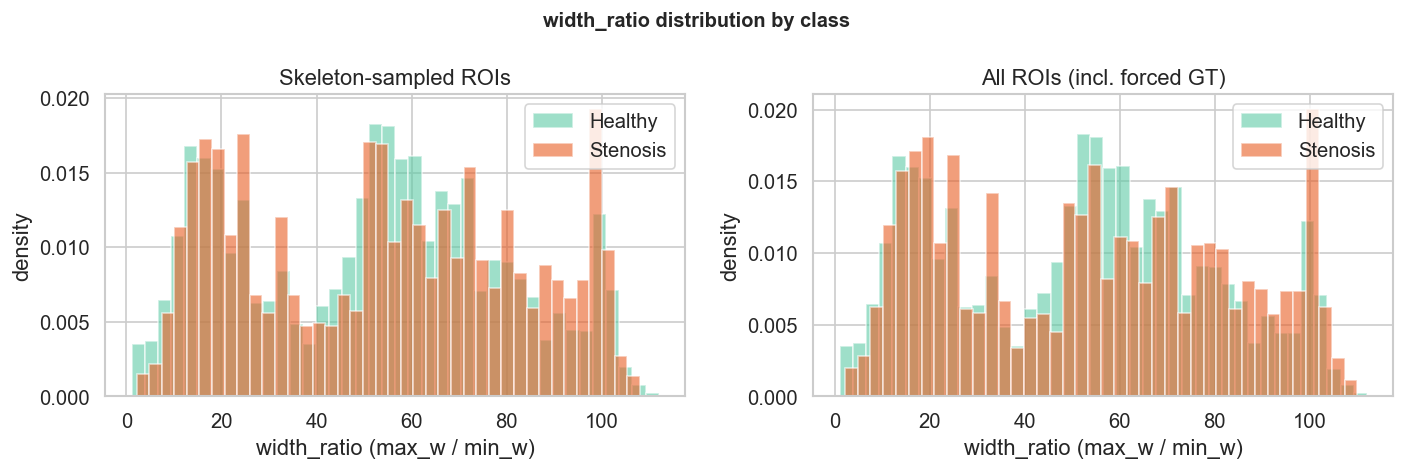

Healthy   : mean=51.592  median=54.000  std=27.459
Stenosis  : mean=54.121  median=55.000  std=28.780


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, subset, title in zip(axes,
                              [sampled, df],
                              ['Skeleton-sampled ROIs', 'All ROIs (incl. forced GT)']):
    for label, color in [(0,'#5DCAA5'),(1,'#E85D24')]:
        vals = subset[subset[TARGET_COL]==label]['width_ratio'].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color,
                label='Healthy' if label==0 else 'Stenosis', density=True)
    ax.set_xlabel('width_ratio (max_w / min_w)')
    ax.set_ylabel('density')
    ax.set_title(title)
    ax.legend()

plt.suptitle('width_ratio distribution by class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
for label, name in [(0,'Healthy'),(1,'Stenosis')]:
    vals = sampled[sampled[TARGET_COL]==label]['width_ratio'].dropna()
    print(f'{name:10s}: mean={vals.mean():.3f}  median={vals.median():.3f}  std={vals.std():.3f}')

Percentil 99 width_ratio: 103.00
Máximo absoluto         : 112.00
Valores > p99           : 374


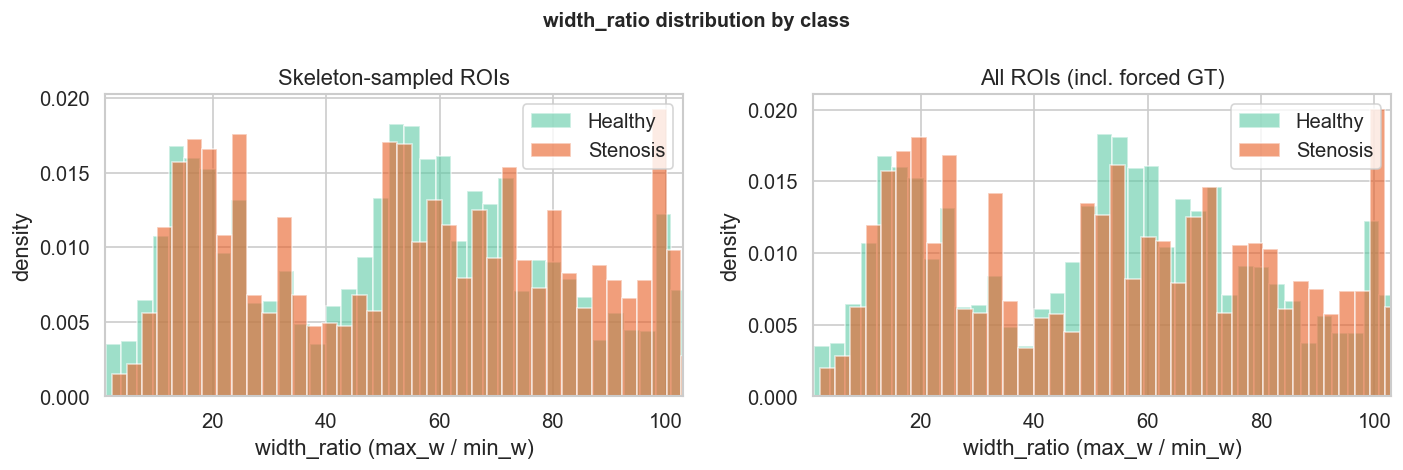

In [30]:
# Calcular límite razonable (percentil 99 de todos los valores)
p99 = sampled['width_ratio'].quantile(0.99)
print(f'Percentil 99 width_ratio: {p99:.2f}')
print(f'Máximo absoluto         : {sampled["width_ratio"].max():.2f}')
print(f'Valores > p99           : {(sampled["width_ratio"] > p99).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, subset, title in zip(axes,
                              [sampled, df],
                              ['Skeleton-sampled ROIs', 'All ROIs (incl. forced GT)']):
    for label, color in [(0,'#5DCAA5'),(1,'#E85D24')]:
        vals = subset[subset[TARGET_COL]==label]['width_ratio'].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color,
                label='Healthy' if label==0 else 'Stenosis', density=True)
    ax.set_xlabel('width_ratio (max_w / min_w)')
    ax.set_ylabel('density')
    ax.set_title(title)
    ax.set_xlim(1, p99)   # ← limitar eje X
    ax.legend()

plt.suptitle('width_ratio distribution by class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10 · Feature-feature correlation heatmap

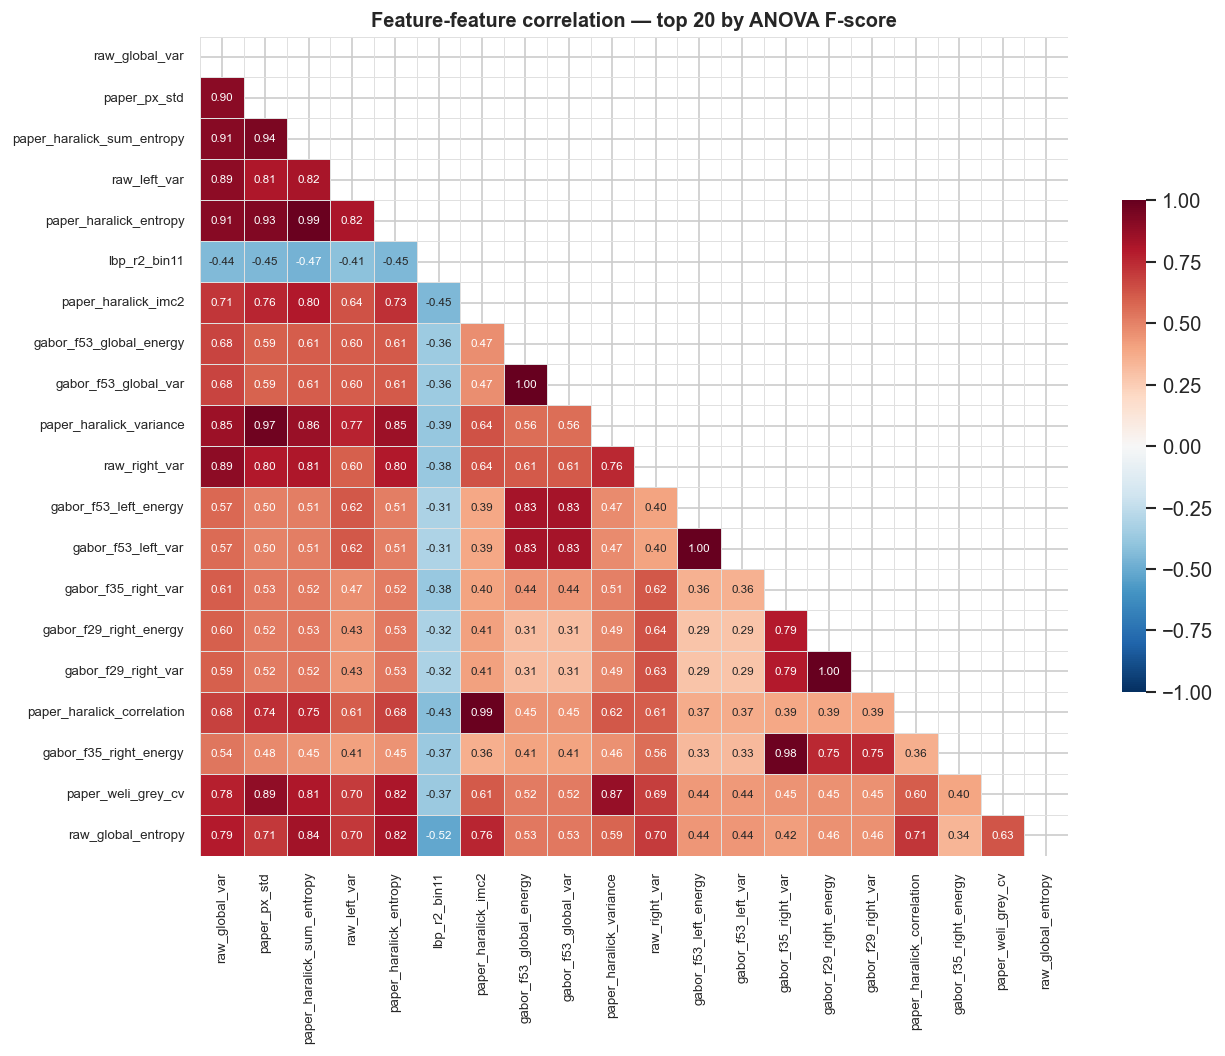

Highly correlated pairs (|r|>0.90): 12
  raw_global_var  ↔  paper_px_std  :  r=0.9
  raw_global_var  ↔  paper_haralick_sum_entropy  :  r=0.914
  raw_global_var  ↔  paper_haralick_entropy  :  r=0.907
  paper_px_std  ↔  paper_haralick_sum_entropy  :  r=0.94
  paper_px_std  ↔  paper_haralick_entropy  :  r=0.927
  paper_px_std  ↔  paper_haralick_variance  :  r=0.971
  paper_haralick_sum_entropy  ↔  paper_haralick_entropy  :  r=0.991
  paper_haralick_imc2  ↔  paper_haralick_correlation  :  r=0.991
  gabor_f53_global_energy  ↔  gabor_f53_global_var  :  r=1.0
  gabor_f53_left_energy  ↔  gabor_f53_left_var  :  r=1.0
  gabor_f35_right_var  ↔  gabor_f35_right_energy  :  r=0.977
  gabor_f29_right_energy  ↔  gabor_f29_right_var  :  r=1.0


In [26]:
## 10 · Feature-feature correlation heatmap (top 20 by ANOVA F-score)

TOP_CORR = 20
top20_corr = anova_df.head(TOP_CORR)['feature'].tolist()
corr_matrix = sampled[top20_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', annot_kws={'size': 7},
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='#e0e0e0', ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title(f'Feature-feature correlation — top {TOP_CORR} by ANOVA F-score',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.show()

# Highly correlated pairs
high_corr = []
for i in range(len(top20_corr)):
    for j in range(i+1, len(top20_corr)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.90:
            high_corr.append((top20_corr[i], top20_corr[j], round(r, 3)))

print(f'Highly correlated pairs (|r|>0.90): {len(high_corr)}')
for a, b, r in high_corr[:15]:
    print(f'  {a}  ↔  {b}  :  r={r}')

## 13 · Outlier detection

In [28]:
X_clean      = sampled[feature_cols].fillna(sampled[feature_cols].median())
z_scores     = np.abs(stats.zscore(X_clean, nan_policy='omit'))
outlier_mask = (z_scores > 4).any(axis=1)

print(f'Rows |z|>4 in any feature: {outlier_mask.sum()} ({outlier_mask.sum()/len(sampled)*100:.1f}%)')
print('By class:')
print(sampled.loc[outlier_mask, TARGET_COL].value_counts().rename({0:'Healthy', 1:'Stenosis', -1:'Undetermined'}))

out_per_feat = pd.Series((z_scores > 4).sum(axis=0), index=feature_cols)
print('\nTop 10 features with most outlier rows:')
print(out_per_feat.sort_values(ascending=False).head(10).to_string())

Rows |z|>4 in any feature: 24147 (53.9%)
By class:
label
Healthy         20788
Undetermined     1884
Stenosis         1475
Name: count, dtype: int64

Top 10 features with most outlier rows:
lbp_r1_bin0               562
gabor_f18_right_energy    545
gabor_f12_right_energy    544
gabor_f12_right_var       543
gabor_f18_right_var       540
gabor_f30_right_energy    532
gabor_f30_right_var       531
gabor_f24_right_var       528
gabor_f24_right_energy    528
gabor_f48_right_energy    525


In [29]:
# Cuántas features outlier tiene cada ROI de media
n_outlier_feats_per_roi = (z_scores > 4).sum(axis=1)
print("Features outlier por ROI:")
print(pd.Series(n_outlier_feats_per_roi).describe())
print(f"\nROIs con >10 features outlier : {(n_outlier_feats_per_roi > 10).sum()}")
print(f"ROIs con >50 features outlier : {(n_outlier_feats_per_roi > 50).sum()}")
print(f"ROIs con >100 features outlier: {(n_outlier_feats_per_roi > 100).sum()}")

Features outlier por ROI:
count    44800.000000
mean         6.763906
std         13.194911
min          0.000000
25%          0.000000
50%          1.000000
75%          7.000000
max        223.000000
dtype: float64

ROIs con >10 features outlier : 8673
ROIs con >50 features outlier : 929
ROIs con >100 features outlier: 38


## 14 · Summary & next steps

In [ ]:
vc_s = sampled[TARGET_COL].value_counts()

print('=' * 65)
print('DATA EXPLORATION SUMMARY')
print('=' * 65)
print(f'Total ROIs in CSV              : {len(df):,}')
print(f'  Skeleton-sampled (roi_idx≤100): {len(sampled):,}')
print(f'  Forced GT (roi_idx>100)       : {len(forced):,}  ← exclude from test set')
print()
print(f'Skeleton-sampled class balance:')
print(f'  Healthy   : {vc_s.get(0,0):,}')
print(f'  Stenosis  : {vc_s.get(1,0):,}')
print(f'  Ratio     : {vc_s.get(0,0)/max(vc_s.get(1,1),1):.1f}:1')
print()
print(f'Total feature columns          : {len(feature_cols)}')
print(f'Missing values                 : {df[feature_cols].isna().sum().sum()}')
print(f'ANOVA sig. features (p<0.05)   : {sig} / {len(feature_cols)}')
print(f'PCA components for 80% var     : {n80}')
print(f'PCA components for 95% var     : {n95}')
print(f'Outlier rows (|z|>4)           : {outlier_mask.sum()}')
print(f'Patients with 0 stenosis ROIs  : {zero_stenosis_patients}')
print()
print('NEXT STEPS')
print('-' * 65)
print('1. Resolve with Bria: include/exclude patients with 0 stenosis ROIs?')
print('2. Create train/test split at PATIENT level (no leakage)')
print('3. For TEST set: drop all forced GT rows (roi_idx > 100)')
print('4. For TRAIN set: keep forced GT rows (extra positive signal)')
print('5. Handle NaNs via median imputation (fit on train, apply to test)')
print('6. Random downsampling on train set only')
print('7. Feature selection: RF importance + SelectKBest (ANOVA F-test)')
print('8. Hard negative mining on full unbalanced train set')
print('9. Baseline: Logistic Regression → XGBoost / RF / SVM / LightGBM')
print('10. GridSearchCV optimising F1-score; soft-voting ensemble if gains')